In [1]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

Real_folder = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\real"

Fake_folder = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\fake"

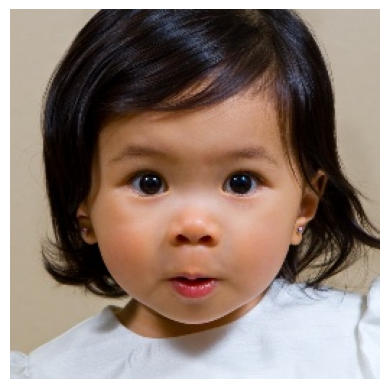

In [2]:
image_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\real\00003.jpg"  # Replace with your actual file path
img = Image.open(image_path)

# 2. Display the image
plt.imshow(img)
plt.axis("off")  # Removes the pixel coordinates/grid lines on the axes
plt.show()

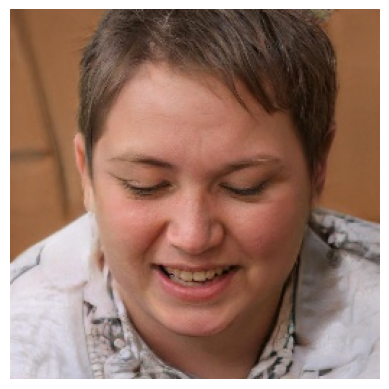

In [3]:
image_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train\fake\0BYS14GRLS.jpg"  # Replace with your actual file path
img = Image.open(image_path)

# 2. Display the image
plt.imshow(img)
plt.axis("off")  
plt.show()

In [4]:
real_files = [
    f for f in os.listdir(Real_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

fake_files = [
    f for f in os.listdir(Fake_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of real images:", len(real_files))
print("Number of fake images:", len(fake_files))

print("\nFirst 5 real files:")
print(real_files[:5])

print("\nFirst 5 fake files:")
print(fake_files[:5])

Number of real images: 3500
Number of fake images: 3500

First 5 real files:
['00000.jpg', '00003.jpg', '00009.jpg', '00030.jpg', '00035.jpg']

First 5 fake files:
['002KDWZBHU.jpg', '009X14ED19.jpg', '00GYML2PNL.jpg', '017VGJOA5T.jpg', '019MPFQ50W.jpg']


In [5]:
# Check dimensions and color channels

real_img = Image.open(os.path.join(Real_folder, real_files[0]))
fake_img = Image.open(os.path.join(Fake_folder, fake_files[0]))

print("Real image:")
print("Size:", real_img.size)
print("Mode:", real_img.mode)

print("\nFake image:")
print("Size:", fake_img.size)
print("Mode:", fake_img.mode)

Real image:
Size: (256, 256)
Mode: RGB

Fake image:
Size: (256, 256)
Mode: RGB


In [17]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Load one real and one fake image
real_path = os.path.join(Real_folder, real_files[0])
fake_path = os.path.join(Fake_folder, fake_files[0])

real_img = Image.open(real_path).convert("RGB")
fake_img = Image.open(fake_path).convert("RGB")

# Resize to Inception-v3 input size
real_resized = real_img.resize((342 , 342))
fake_resized = fake_img.resize((342, 342))

print("Original real:", real_img.size)
print("Resized real:", real_resized.size)

print("Original fake:", fake_img.size)
print("Resized fake:", fake_resized.size)

Original real: (256, 256)
Resized real: (342, 342)
Original fake: (256, 256)
Resized fake: (342, 342)


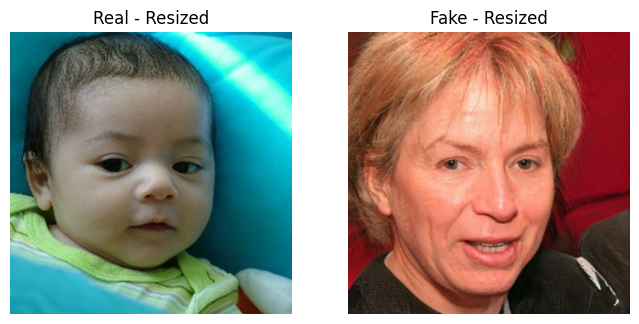

In [18]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(real_resized)
plt.title("Real - Resized")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(fake_resized)
plt.title("Fake - Resized")
plt.axis("off")

plt.show()

In [10]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu


In [1]:
import torch
from torchvision.models import inception_v3, Inception_V3_Weights

# Load the official ImageNet-pretrained Inception-v3 weights
weights = Inception_V3_Weights.DEFAULT

model = inception_v3(weights=weights)

# We are only extracting features, so use evaluation mode
model.eval()

# CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)
print("Model loaded successfully.")

Device: cpu
Model loaded successfully.


In [2]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# RVF10K training dataset
data_path = r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\train"

# Exact preprocessing for the pretrained Inception-v3 weights
preprocess = weights.transforms()

# Load images
dataset = ImageFolder(
    root=data_path,
    transform=preprocess
)

print("Number of images:", len(dataset))
print("Classes:", dataset.class_to_idx)

Number of images: 7000
Classes: {'fake': 0, 'real': 1}


In [3]:
batch_size = 32

data_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Batch size:", batch_size)
print("Number of batches:", len(data_loader))

Batch size: 32
Number of batches: 219


In [4]:
# Get one batch
images, labels = next(iter(data_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Move images to the same device as the model
images = images.to(device)

# Run one batch through Inception-v3
with torch.inference_mode():
    output = model(images)

print("Model output shape:", output.shape)

Image batch shape: torch.Size([32, 3, 299, 299])
Label batch shape: torch.Size([32])
Model output shape: torch.Size([32, 1000])


In [5]:
# Replace the final 1000-class classifier with an identity layer
model.fc = torch.nn.Identity()

# Run the same batch again
with torch.inference_mode():
    features = model(images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([32, 2048])


In [6]:
import numpy as np
from tqdm import tqdm

all_features = []
all_labels = []

model.eval()

with torch.inference_mode():
    for images, labels in tqdm(data_loader, desc="Extracting Inception features"):
        images = images.to(device)

        features = model(images)

        # Move features back to CPU and store them
        all_features.append(features.cpu())
        all_labels.append(labels)

# Combine all batches
all_features = torch.cat(all_features, dim=0)
all_labels = torch.cat(all_labels, dim=0)

print("Features shape:", all_features.shape)
print("Labels shape:", all_labels.shape)

Extracting Inception features: 100%|██████████| 219/219 [45:22<00:00, 12.43s/it] 

Features shape: torch.Size([7000, 2048])
Labels shape: torch.Size([7000])


In [7]:
# Separate the features according to their labels
real_features = all_features[all_labels == 1]
fake_features = all_features[all_labels == 0]

print("Real features shape:", real_features.shape)
print("Fake features shape:", fake_features.shape)

Real features shape: torch.Size([3500, 2048])
Fake features shape: torch.Size([3500, 2048])


In [8]:
# Convert to NumPy arrays
real_features_np = real_features.numpy()
fake_features_np = fake_features.numpy()

# Save them
np.save(
    r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\real_inception_features.npy",
    real_features_np
)

np.save(
    r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\fake_inception_features.npy",
    fake_features_np
)

print("Real features saved:", real_features_np.shape)
print("Fake features saved:", fake_features_np.shape)

Real features saved: (3500, 2048)
Fake features saved: (3500, 2048)


In [9]:
# Calculate the mean feature vector for each distribution

mu_real = np.mean(real_features_np, axis=0)
mu_fake = np.mean(fake_features_np, axis=0)

print("Real mean shape:", mu_real.shape)
print("Fake mean shape:", mu_fake.shape)

print("\nFirst 10 values of real mean:")
print(mu_real[:10])

print("\nFirst 10 values of fake mean:")
print(mu_fake[:10])

Real mean shape: (2048,)
Fake mean shape: (2048,)

First 10 values of real mean:
[0.2837937  0.38183638 0.1864621  0.42582285 0.34045357 0.32413715
 0.32799682 0.24458818 0.26196563 0.29587108]

First 10 values of fake mean:
[0.26011416 0.37024558 0.15907331 0.47212657 0.37235636 0.3382308
 0.34180117 0.23791927 0.27460685 0.33977723]


In [10]:
# Calculate covariance matrices

sigma_real = np.cov(real_features_np, rowvar=False)
sigma_fake = np.cov(fake_features_np, rowvar=False)

print("Real covariance shape:", sigma_real.shape)
print("Fake covariance shape:", sigma_fake.shape)

Real covariance shape: (2048, 2048)
Fake covariance shape: (2048, 2048)


In [11]:
# Squared distance between the real and fake mean vectors

mean_difference = mu_real - mu_fake

mean_term = np.sum(mean_difference ** 2)

print("Mean difference term:", mean_term)

Mean difference term: 5.14542


In [12]:
# Matrix product of the two covariance matrices

covariance_product = sigma_real @ sigma_fake

print("Covariance product shape:", covariance_product.shape)

Covariance product shape: (2048, 2048)


In [ ]:
#we cant use numpy sqrt function as it will take sqrt of every element of the matrix thats y used this functionn

from scipy.linalg import sqrtm

covmean = sqrtm(covariance_product)

print("Matrix square root shape:", covmean.shape)
print("Contains complex values:", np.iscomplexobj(covmean))

Matrix square root shape: (2048, 2048)
Contains complex values: False


In [ ]:
# Calculate the covariance term of FID

covariance_term_matrix = (sigma_real + sigma_fake - 2 * covmean)

covariance_term = np.trace(covariance_term_matrix)

print("Covariance term:", covariance_term)

Covariance term: 14.143613868439187


In [15]:
# Final FID score

fid = mean_term + covariance_term

print("FID score:", fid)

FID score: 19.28903394290208


In [16]:
# Check whether covariance matrices are symmetric

real_symmetry_error = np.max(np.abs(sigma_real - sigma_real.T))
fake_symmetry_error = np.max(np.abs(sigma_fake - sigma_fake.T))

print("Real covariance symmetry error:", real_symmetry_error)
print("Fake covariance symmetry error:", fake_symmetry_error)

Real covariance symmetry error: 0.0
Fake covariance symmetry error: 0.0


In [17]:
real_eigenvalues = np.linalg.eigvalsh(sigma_real)
fake_eigenvalues = np.linalg.eigvalsh(sigma_fake)

print("Real minimum eigenvalue:", real_eigenvalues.min())
print("Fake minimum eigenvalue:", fake_eigenvalues.min())

print("Real eigenvalues < -1e-10:", np.sum(real_eigenvalues < -1e-10))
print("Fake eigenvalues < -1e-10:", np.sum(fake_eigenvalues < -1e-10))

Real minimum eigenvalue: 0.00017685848286858085
Fake minimum eigenvalue: 0.00011253023659770059
Real eigenvalues < -1e-10: 0
Fake eigenvalues < -1e-10: 0


In [18]:
sqrt_reconstruction = covmean @ covmean

sqrt_error = np.max(
    np.abs(sqrt_reconstruction - covariance_product)
)

print("Matrix square-root reconstruction error:", sqrt_error)

Matrix square-root reconstruction error: 4.085620730620576e-14


Real features: (3500, 2048)
Fake features: (3500, 2048)
PC1 explained variance: 0.13375339
PC2 explained variance: 0.072541274
Total explained variance: 0.20629466


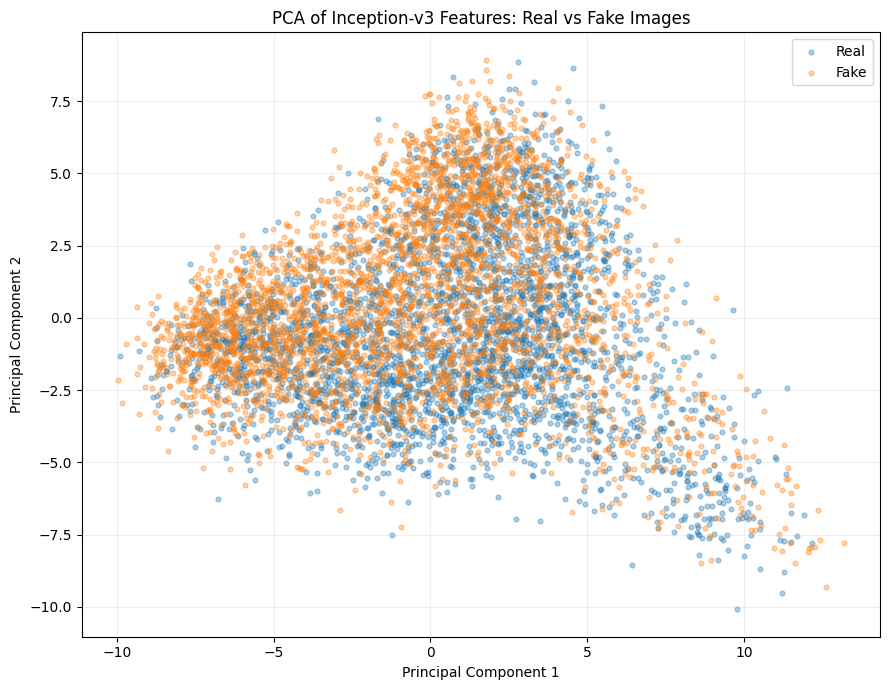

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load the saved Inception features
real_features = np.load(
    r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\real_inception_features.npy"
)

fake_features = np.load(
    r"E:\Research Datasets\Datasets\RealvsFake\rvf10k\fake_inception_features.npy"
)

print("Real features:", real_features.shape)
print("Fake features:", fake_features.shape)

# Combine real and fake features
all_features = np.vstack([real_features, fake_features])

# Create labels
labels = np.array(
    ["Real"] * len(real_features) +
    ["Fake"] * len(fake_features)
)

# PCA: reduce 2048 dimensions to 2
pca = PCA(n_components=2)
features_2d = pca.fit_transform(all_features)

# Explained variance
print("PC1 explained variance:", pca.explained_variance_ratio_[0])
print("PC2 explained variance:", pca.explained_variance_ratio_[1])
print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

# Separate the two groups
real_2d = features_2d[labels == "Real"]
fake_2d = features_2d[labels == "Fake"]

# Plot
plt.figure(figsize=(9, 7))

plt.scatter(
    real_2d[:, 0],
    real_2d[:, 1],
    alpha=0.35,
    s=12,
    label="Real"
)

plt.scatter(
    fake_2d[:, 0],
    fake_2d[:, 1],
    alpha=0.35,
    s=12,
    label="Fake"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Inception-v3 Features: Real vs Fake Images")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

PC1 explained variance: 0.1337534
PC2 explained variance: 0.072541304
PC3 explained variance: 0.058798578
Total explained variance: 0.2650933


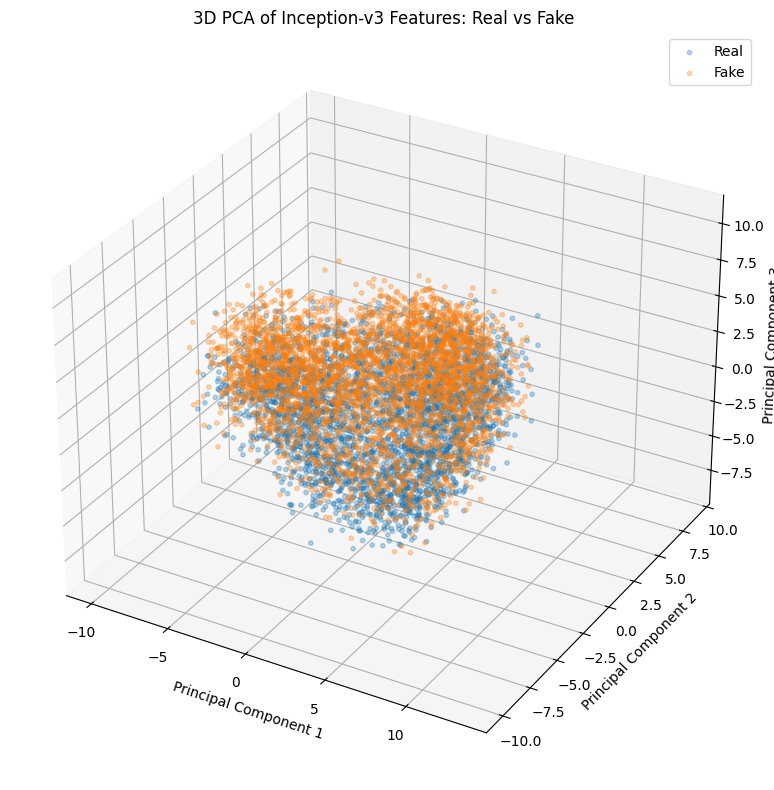

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Combine the existing features
all_features = np.vstack([real_features, fake_features])

# PCA to 3 dimensions
pca_3d = PCA(n_components=3)
features_3d = pca_3d.fit_transform(all_features)

# Split back into real and fake
real_3d = features_3d[:len(real_features)]
fake_3d = features_3d[len(real_features):]

# Explained variance
print("PC1 explained variance:", pca_3d.explained_variance_ratio_[0])
print("PC2 explained variance:", pca_3d.explained_variance_ratio_[1])
print("PC3 explained variance:", pca_3d.explained_variance_ratio_[2])
print("Total explained variance:",
      pca_3d.explained_variance_ratio_.sum())

# 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    real_3d[:, 0],
    real_3d[:, 1],
    real_3d[:, 2],
    alpha=0.3,
    s=10,
    label="Real"
)

ax.scatter(
    fake_3d[:, 0],
    fake_3d[:, 1],
    fake_3d[:, 2],
    alpha=0.3,
    s=10,
    label="Fake"
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("3D PCA of Inception-v3 Features: Real vs Fake")
ax.legend()

plt.tight_layout()
plt.show()